# Ego-Recall Exploratory Data Analysis

**Project:** EgoRecall · Visual Memory Retrieval for Smart Glasses  
**Dataset:** Ego4D Visual Object Queries (VQ) Benchmark  
**Annotations:** `vq_train.json` (1321 videos) and `vq_val.json` (422 videos)

EGO4D is the world's largest egocentric (first person) video ML dataset and benchmark suite, with 3,600 hrs (and counting) of densely narrated video and a wide range of annotations across five new benchmark tasks. It covers hundreds of scenarios (household, outdoor, workplace, leisure, etc.) of daily life activity captured in-the-wild by 926 unique camera wearers from 74 worldwide locations and 9 different countries. Portions of the video are accompanied by audio, 3D meshes of the environment, eye gaze, stereo, and/or synchronized videos from multiple egocentric cameras at the same even

### Episodic Memory

Given an egocentric video and a query, the Ego4D Episodic Memory task requires localizing where the answer can be seen within the user’s past video. For our project we are making use of the Visual Query (VQ) type:

In which the query is a static image of an object, and the output response localizes the object the last time it was seen in the video, both temporally and spatially.

The spatial response is a 2D bounding box on the object, and optionally a 3D displacement vector from the current camera position to the object’s 3D bounding box. (**note; we would likely be focusing on the 2D**)

VQ captures how a user might teach the system an object with an image example, then later ask for its location (“Where is this [picture of my keys]?”).

## Imports

In [1]:
from google.colab import auth
from google.cloud import storage
import json
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


import os
from pathlib import Path
from collections import Counter, defaultdict

In [2]:
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
COLORS = {"train": "#4C72B0", "val": "#DD8452"}

## Authentication

In [3]:
auth.authenticate_user()

In [4]:
client = storage.Client(project='visual-memory-acv-project')
bucket = client.bucket('egorecall-data')

# Load Schema

In this section, we want to understand the file structure

In [5]:
TRAIN_PATH = bucket.blob('ego4d/v2/annotations/vq_train.json')
VAL_PATH = bucket.blob('ego4d/v2/annotations/vq_val.json')

print("Train exists:", TRAIN_PATH.exists())
print("Val   exists:", VAL_PATH.exists())

Train exists: True
Val   exists: True


In [6]:
train_raw = json.loads(TRAIN_PATH.download_as_string())
val_raw = json.loads(VAL_PATH.download_as_string())

In [7]:
print("Train Data Info \n")
print(f"  version    : {train_raw['version']}")
print(f"  date       : {train_raw['date']}")
print(f"  top-level keys: {list(train_raw.keys())}")
print(f"  num videos : {len(train_raw['videos'])}")

Train Data Info 

  version    : 1.0.5
  date       : 220806
  top-level keys: ['version', 'date', 'description', 'metadata', 'videos']
  num videos : 1321


In [8]:
print("Val Data Info \n")
print(f"  num videos : {len(val_raw['videos'])}")

Val Data Info 

  num videos : 422


**Schema Walkthrough on a single video**

In [9]:
sample_video = train_raw["videos"][0]
sample_clip  = sample_video["clips"][0]
sample_anno  = sample_clip["annotations"][0]
sample_qs    = sample_anno["query_sets"]["1"]

print("Video keys    :", list(sample_video.keys()))
print("Clip keys     :", [k for k in sample_clip.keys() if k != "annotations"])
print("Annotation keys:", list(sample_anno.keys()))
print("Query-set keys :", list(sample_qs.keys()))
print("\nSample object_title:", sample_qs["object_title"])
print("Query frame (clip):", sample_qs["query_frame"],
      "| Query frame (video):", sample_qs["query_video_frame"])
print("Visual crop frame :", sample_qs["visual_crop"]["frame_number"])
print("Response track len:", len(sample_qs["response_track"]))
print("Response track[0] :", sample_qs["response_track"][0])

Video keys    : ['video_uid', 'split', 'clips']
Clip keys     : ['clip_uid', 'video_start_sec', 'video_end_sec', 'video_start_frame', 'video_end_frame', 'clip_start_sec', 'clip_end_sec', 'clip_start_frame', 'clip_end_frame', 'clip_fps', 'annotation_complete', 'source_clip_uid']
Annotation keys: ['query_sets', 'warnings', 'annotation_uid']
Query-set keys : ['is_valid', 'errors', 'warnings', 'query_frame', 'query_video_frame', 'response_track', 'object_title', 'visual_crop']

Sample object_title: mr krips
Query frame (clip): 1190 | Query frame (video): 15239
Visual crop frame : 1198
Response track len: 11
Response track[0] : {'frame_number': 1099, 'x': 929.68, 'y': 540.42, 'width': 11.2, 'height': 41.4, 'rotation': 0, 'original_width': 1440, 'original_height': 1080, 'video_frame_number': 14693}


# Flatten Annotations into a DataFrame

One row = one query set

- A query set is the atomic retrieval unit: i.e the single object query inside a clip.

- This is the grain at which we evaluate both detection and retrieval

In [10]:
import numpy as np # Import numpy for np.nan

def flatten_annotations(raw: dict, split: str) -> pd.DataFrame:
    """
    Flatten the nested Ego4D VQ structure into one row per query-set.

    Columns
    -------
    split, video_uid, clip_uid, source_clip_uid,
    annotation_uid, qs_id,
    object_title,
    query_frame (clip-relative), query_video_frame,
    is_valid, has_errors, has_warnings,
    response_track_len,
    visual_crop_frame, visual_crop_w, visual_crop_h,
    visual_crop_x, visual_crop_y,
    orig_w, orig_h,
    clip_fps, clip_start_sec, clip_end_sec, clip_duration_sec,
    video_start_sec, video_end_sec,
    annotation_complete,
    """
    rows = []
    for video in raw["videos"]:
        vid = video["video_uid"]
        for clip in video["clips"]:
            # Safely get clip start and end seconds
            clip_start_sec = clip.get("clip_start_sec")
            clip_end_sec = clip.get("clip_end_sec")

            clip_duration_sec = None
            if clip_start_sec is not None and clip_end_sec is not None:
                clip_duration_sec = clip_end_sec - clip_start_sec

            clip_meta = {
                "clip_uid"         : clip["clip_uid"],
                "source_clip_uid"  : clip["source_clip_uid"],
                "clip_fps"         : clip["clip_fps"],
                "clip_start_sec"   : clip_start_sec,
                "clip_end_sec"     : clip_end_sec,
                "clip_duration_sec": clip_duration_sec,
                "video_start_sec"  : clip["video_start_sec"],
                "video_end_sec"    : clip["video_end_sec"],
                "annotation_complete": clip["annotation_complete"],
            }
            for anno in clip["annotations"]:
                for qs_id, qs in anno["query_sets"].items():
                    vc = qs.get("visual_crop", {})
                    rows.append({
                        "split"            : split,
                        "video_uid"        : vid,
                        "annotation_uid"   : anno["annotation_uid"],
                        "qs_id"            : qs_id,
                        "object_title"     : qs.get("object_title", "").strip().lower(),
                        "query_frame"      : qs.get("query_frame"),
                        "query_video_frame": qs.get("query_video_frame"),
                        "is_valid"         : qs.get("is_valid", False),
                        "has_errors"       : len(qs.get("errors", [])) > 0,
                        "has_warnings"     : len(qs.get("warnings", [])) > 0,
                        "response_track_len": len(qs.get("response_track", [])),
                        # Visual crop geometry
                        "vc_frame"         : vc.get("frame_number"),
                        "vc_x"             : vc.get("x"),
                        "vc_y"             : vc.get("y"),
                        "vc_w"             : vc.get("width"),
                        "vc_h"             : vc.get("height"),
                        "orig_w"           : vc.get("original_width"),
                        "orig_h"           : vc.get("original_height"),
                        **clip_meta,
                    })
    return pd.DataFrame(rows)

train_df = flatten_annotations(train_raw, "train")
val_df   = flatten_annotations(val_raw,   "val")
df       = pd.concat([train_df, val_df], ignore_index=True)

# Derived columns
df["vc_area_norm"] = (df["vc_w"] * df["vc_h"]) / (df["orig_w"] * df["orig_h"])
df["vc_cx_norm"]   = (df["vc_x"] + df["vc_w"] / 2) / df["orig_w"]
df["vc_cy_norm"]   = (df["vc_y"] + df["vc_h"] / 2) / df["orig_h"]
df["vc_aspect"]    = df["vc_w"] / df["vc_h"].replace(0, np.nan)

print(f"Total query-sets : {len(df):,}")
print(f"  train          : {len(train_df):,}")
print(f"  val            : {len(val_df):,}")
df.head(3)


Total query-sets : 18,219
  train          : 13,692
  val            : 4,527


,split,video_uid,annotation_uid,qs_id,object_title,query_frame,query_video_frame,is_valid,has_errors,has_warnings,...,clip_start_sec,clip_end_sec,clip_duration_sec,video_start_sec,video_end_sec,annotation_complete,vc_area_norm,vc_cx_norm,vc_cy_norm,vc_aspect
0,train,56a3b49c-6979-4253-9ff5-2733c3e2f229,c64628fc-f163-4eb6-b7b1-f89b35cdcf54,1,mr krips,1190.0,15239.0,True,False,True,...,0.0,300.0,300.0,269.987695,569.987695,True,0.006133,0.542538,0.600069,0.643638
1,train,56a3b49c-6979-4253-9ff5-2733c3e2f229,c64628fc-f163-4eb6-b7b1-f89b35cdcf54,2,oats & more,1176.0,15155.0,True,False,True,...,0.0,300.0,300.0,269.987695,569.987695,True,0.052142,0.689042,0.591903,0.265028
2,train,56a3b49c-6979-4253-9ff5-2733c3e2f229,c64628fc-f163-4eb6-b7b1-f89b35cdcf54,3,tissue,1339.0,16133.0,True,False,True,...,0.0,300.0,300.0,269.987695,569.987695,True,0.009538,0.718073,0.338042,0.626356


### Understanding the output

**Identity columns**

- video_uid: This is the top level Ego4D video. In the table above, all the 3 rows share the same video_uid starting with *56a3b49c*, this is because they come from the same source video

- clip_uid: All the three queries also share the same clip_uid, meaning that they are from the same clip within that video

- annotation_uid: all three also share the same annotation_uid, meaning that they belong to the same annotation bundle. One annotator sat down with one clip and labeled the three objects in that clip -> thus producing the three query sets

- qs_id: In the table above we have 3 different qs_id namely; 1, 2 and 3. Which correponds to mr krips, oats & more and tissue


**Retrieval problem analysis from a single row**

Lets take the first row with "mr krips"

- query_frame: 1190 - This is the frame 1190 for that clip. In this frame the object (mr krips) is likely absent. **Note; i need to verify this, as in the benchmark design - they mentioned that the task is defines such that query_frame is a frame where the object is not visible in the frame), but we would need to do a manual validation**

- query_video_frame: same moment as query_frame, but indexed from the start of the full source video rather than the clip. You'll need this when extracting frames from the raw video file.

- vc_frame: 1198 — the visual crop (the reference image of the object) was captured at clip frame 1198, which is after the query frame (1190). This means the annotator looked forward in the video to find a clean still of the object to use as the retrieval query image.

vc_x: 742, vc_y: 587, vc_w: 78, vc_h: 122 — the bounding box of that reference crop in a 1440×1080 frame. A fairly small object (~78×122 px out of 1440×1080).


- response_track_len: 11 —  The response track is the sequence of bounding boxes showing where the object was in the frames before it disappeared. Each entry is one frame where an annotator drew a box around the object.  11 here imply means there are 11 such boxes — the object was annotated across 11 frames before the query frame. there are 11 annotated bounding boxes showing where the object was before it disappeared. This is the ground truth for detection training.





# Split Level Statistics

In [12]:
# ── Counts at each level of the hierarchy ─────────────────────────────────
summary = []
for split, raw in [("train", train_raw), ("val", val_raw)]:
    n_videos = len(raw["videos"])
    n_clips  = sum(len(v["clips"]) for v in raw["videos"])
    n_annos  = sum(
        len(c["annotations"])
        for v in raw["videos"]
        for c in v["clips"]
    )
    n_qs = sum(
        len(a["query_sets"])
        for v in raw["videos"]
        for c in v["clips"]
        for a in c["annotations"]
    )
    summary.append({
        "split": split,
        "videos": n_videos,
        "clips": n_clips,
        "annotations": n_annos,
        "query_sets": n_qs,
        "qs_per_clip": round(n_qs / n_clips, 2),
    })

summary_df = pd.DataFrame(summary).set_index("split")
print(summary_df.to_string())

       videos  clips  annotations  query_sets  qs_per_clip
split                                                     
train    1321   3538         4564       13692         3.87
val       422   1159         1508        4527         3.91


**Insights**

- Videos → Clips (~2.7 per video): Each source video gets chopped into shorter segments. A 10-minute kitchen video might yield 2–3 clips, each covering a different activity window.

- Clips → Annotations (~1.3 per clip): Most clips have exactly one annotation bundle, but some clips were annotated twice — either by a second annotator for quality control, or because the clip was long enough to warrant two independent passes. You saw this in the sample video where one clip had two annotation UIDs (c64628fc... and 69b2bddb...).


- Annotations → Query-sets (~3 per annotation): Each annotator labeled exactly 3 objects per annotation bundle — that's by benchmark design. qs_id is always 1, 2, or 3

- The 3.87 qs_per_clip is just slightly above 3 because of those clips with two annotation bundles — 2 bundles × 3 query-sets = 6 query-sets for that clip, which pulls the average above 3.


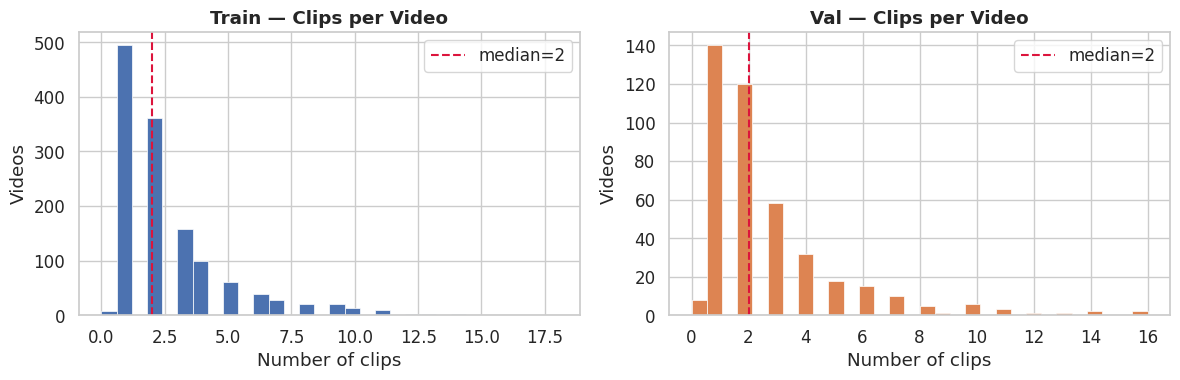

In [13]:
clips_per_video = {
    split: [len(v["clips"]) for v in raw["videos"]]
    for split, raw in [("train", train_raw), ("val", val_raw)]
}

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, (split, counts) in zip(axes, clips_per_video.items()):
    ax.hist(counts, bins=30, color=COLORS[split], edgecolor="white", linewidth=0.5)
    ax.set_title(f"{split.title()} — Clips per Video", fontweight="bold")
    ax.set_xlabel("Number of clips")
    ax.set_ylabel("Videos")
    ax.axvline(np.median(counts), color="crimson", linestyle="--", linewidth=1.5,
               label=f"median={np.median(counts):.0f}")
    ax.legend()

plt.tight_layout()
plt.show()

### Object Level Vocabulary

In [14]:
title_counts = Counter(df["object_title"])
print(f"Unique object titles (combined): {len(title_counts):,}")
print(f"  train: {df[df.split=='train']['object_title'].nunique():,}")
print(f"  val  : {df[df.split=='val']['object_title'].nunique():,}")
print(f"\nTop-20 objects (train+val):")
pd.Series(title_counts).sort_values(ascending=False).head(20)

Unique object titles (combined): 3,487
  train: 2,853
  val  : 1,357

Top-20 objects (train+val):


,0
bottle,600
phone,506
bucket,464
cup,327
chair,244
container,220
bowl,212
bag,176
water bottle,174
hammer,173


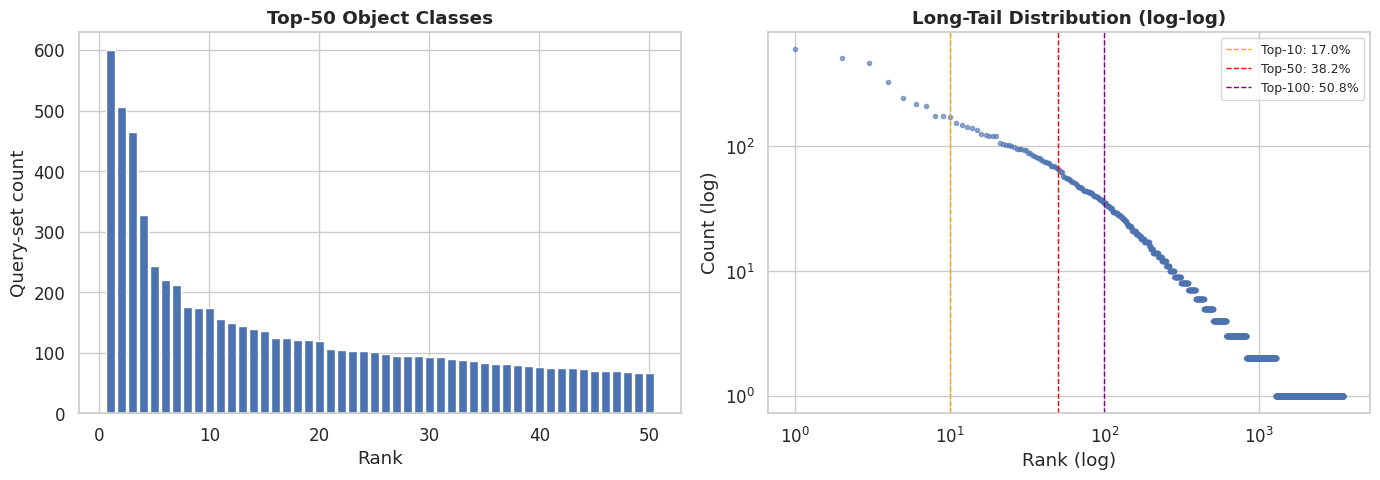

Top- 10 classes cover 17.0% of all query-sets
Top- 50 classes cover 38.2% of all query-sets
Top-100 classes cover 50.8% of all query-sets
Top-200 classes cover 63.5% of all query-sets


In [15]:
counts_sorted = sorted(title_counts.values(), reverse=True)
ranks = np.arange(1, len(counts_sorted) + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Linear rank
axes[0].bar(ranks[:50], counts_sorted[:50], color="#4C72B0")
axes[0].set_title("Top-50 Object Classes", fontweight="bold")
axes[0].set_xlabel("Rank")
axes[0].set_ylabel("Query-set count")

# Log-log tail
axes[1].loglog(ranks, counts_sorted, "o", color="#4C72B0", alpha=0.6, markersize=3)
axes[1].set_title("Long-Tail Distribution (log-log)", fontweight="bold")
axes[1].set_xlabel("Rank (log)")
axes[1].set_ylabel("Count (log)")

# Annotate % covered by top-N classes
for n, color in [(10, "orange"), (50, "red"), (100, "purple")]:
    pct = 100 * sum(counts_sorted[:n]) / sum(counts_sorted)
    axes[1].axvline(n, linestyle="--", color=color, linewidth=1,
                    label=f"Top-{n}: {pct:.1f}%")
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.show()

# Coverage stats
for n in [10, 50, 100, 200]:
    pct = 100 * sum(counts_sorted[:n]) / sum(counts_sorted)
    print(f"Top-{n:3d} classes cover {pct:.1f}% of all query-sets")

In [16]:
# ── Singleton classes (appear only once) — direct challenge for retrieval ──
singletons = [t for t, c in title_counts.items() if c == 1]
print(f"Classes with exactly 1 occurrence: {len(singletons):,}  "
      f"({100*len(singletons)/len(title_counts):.1f}% of vocabulary)")
print("Examples:", singletons[:15])

Classes with exactly 1 occurrence: 2,203  (63.2% of vocabulary)
Examples: ['mr krips', 'oats & more', 'red nylon bag', 'door lock', 'tag', 'safety cylinder', 'dough tray', 'floor scraper', 'lang handle broom', 'bakery bucket', 'brush head', 'baking timer', 'large spoon ladle', 'power adapter', 'thermometer']


### Query Set Validity

       total  valid  has_errors  has_warnings  pct_valid  pct_errors  pct_warnings
split                                                                             
train  13692  13607          85         13692  99.379200    0.620800         100.0
val     4527   4507          20          4527  99.558206    0.441794         100.0


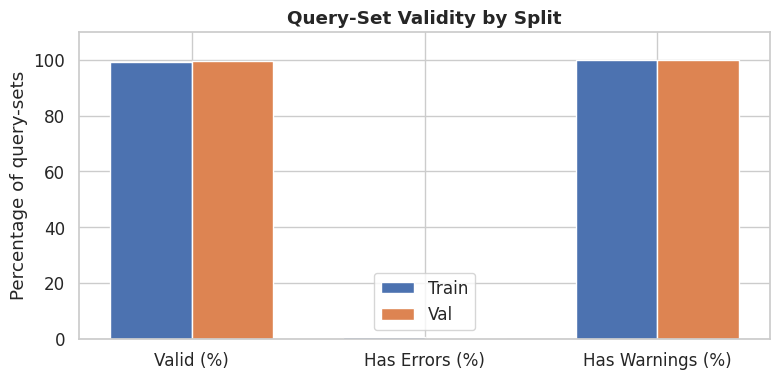

In [17]:
validity = df.groupby("split").agg(
    total=("is_valid", "count"),
    valid=("is_valid", "sum"),
    has_errors=("has_errors", "sum"),
    has_warnings=("has_warnings", "sum"),
).assign(
    pct_valid=lambda x: 100 * x.valid / x.total,
    pct_errors=lambda x: 100 * x.has_errors / x.total,
    pct_warnings=lambda x: 100 * x.has_warnings / x.total,
)
print(validity.to_string())

# Plot
fig, ax = plt.subplots(figsize=(8, 4))
categories = ["pct_valid", "pct_errors", "pct_warnings"]
labels = ["Valid (%)", "Has Errors (%)", "Has Warnings (%)"]
x = np.arange(len(categories))
width = 0.35

for i, (split, color) in enumerate(COLORS.items()):
    vals = [validity.loc[split, c] for c in categories]
    ax.bar(x + i*width, vals, width, label=split.title(), color=color)

ax.set_xticks(x + width/2)
ax.set_xticklabels(labels)
ax.set_ylabel("Percentage of query-sets")
ax.set_title("Query-Set Validity by Split", fontweight="bold")
ax.legend()
ax.set_ylim(0, 110)
plt.tight_layout()
plt.show()

A few things stand out here:

- pct_warnings is 100% for both splits
Every single query-set has at least one warning. Looking back at the raw JSON, the warning on every entry is "Extra query set annotation" — this appears to be a systematic flag the Ego4D team applied to the entire dataset, not a data quality issue. It's essentially noise in the warnings field for our purposes. We can safely ignore has_warnings as a filter.

- pct_valid is ~99.4–99.6%
Almost everything is valid. The 85 invalid train query-sets and 20 invalid val query-sets are a very small fraction. The practical implication is that filtering on is_valid == True costs us less than 1% of your data

- has_errors is the meaningful signal
With errors at 0.62% train and 0.44% val, these are the query-sets we actually want to drop. An error means the annotation is structurally broken in some way — a missing response track, malformed bounding box, etc. Since is_valid and has_errors are essentially the same gate (invalid ≈ has errors), we only need one filter.

# Filtering Errors

In [18]:
df_clean = df[df["is_valid"] == True]

In [20]:
new_validity = df_clean.groupby("split").agg(
    total=("is_valid", "count"),
    valid=("is_valid", "sum"),
    has_errors=("has_errors", "sum"),
    has_warnings=("has_warnings", "sum"),
).assign(
    pct_valid=lambda x: 100 * x.valid / x.total,
    pct_errors=lambda x: 100 * x.has_errors / x.total,
    pct_warnings=lambda x: 100 * x.has_warnings / x.total,
)
print(new_validity.to_string())

       total  valid  has_errors  has_warnings  pct_valid  pct_errors  pct_warnings
split                                                                             
train  13607  13607           0         13607      100.0         0.0         100.0
val     4507   4507           0          4507      100.0         0.0         100.0


### Response Track Analysis

The response track is the sequence of bounding boxes showing where the target object was before it disappeared from view.  
Track length = how many frames of ground-truth object location we have for detection training.

Why the response track matters for our two problems:
- For detection (Problem 1), each of these 11 entries is a labeled training example — a frame + bounding box we can feed to YOLOv8 or DETR.

- For retrieval (Problem 2), the response track tells us the answer to the query. When our model receives the visual crop at frame 1198 and asks "where was this object last seen?", the correct answer is somewhere in frames 1099–1109 at those coordinates.


In [21]:
df = df_clean

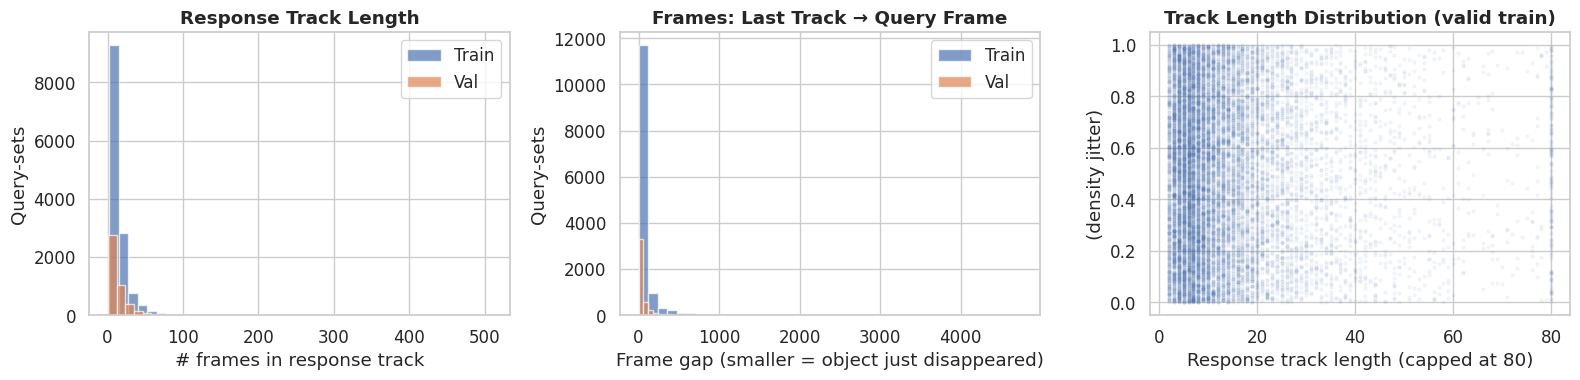

In [22]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# 1. Response track length distribution
for split, color in COLORS.items():
    subset = df[df.split == split]["response_track_len"]
    axes[0].hist(subset, bins=40, alpha=0.7, color=color, label=split.title(), edgecolor="white")
axes[0].set_title("Response Track Length", fontweight="bold")
axes[0].set_xlabel("# frames in response track")
axes[0].set_ylabel("Query-sets")
axes[0].legend()

# 2. Temporal distance: query_frame - last_response_frame
# We need to recompute this from the raw data
gaps = []
for split, raw in [("train", train_raw), ("val", val_raw)]:
    for video in raw["videos"]:
        for clip in video["clips"]:
            for anno in clip["annotations"]:
                for qs_id, qs in anno["query_sets"].items():
                    rt = qs.get("response_track", [])
                    if rt and qs.get("is_valid"):
                        last_rt_frame = max(f["frame_number"] for f in rt)
                        qf = qs["query_frame"]
                        gaps.append({"split": split, "gap": qf - last_rt_frame})

gaps_df = pd.DataFrame(gaps)
for split, color in COLORS.items():
    subset = gaps_df[gaps_df.split == split]["gap"]
    axes[1].hist(subset, bins=40, alpha=0.7, color=color, label=split.title(), edgecolor="white")
axes[1].set_title("Frames: Last Track → Query Frame", fontweight="bold")
axes[1].set_xlabel("Frame gap (smaller = object just disappeared)")
axes[1].set_ylabel("Query-sets")
axes[1].legend()

# 3. Track length vs. gap scatter (valid train only)
valid_train = df[(df.split=="train") & df.is_valid].copy()
gap_map = gaps_df[gaps_df.split=="train"].reset_index(drop=True)
# (approximate — scatter on marginals)
axes[2].scatter(
    valid_train["response_track_len"].clip(upper=80),
    np.random.rand(len(valid_train)),  # jitter to show density
    alpha=0.05, s=5, color=COLORS["train"]
)
axes[2].set_title("Track Length Distribution (valid train)", fontweight="bold")
axes[2].set_xlabel("Response track length (capped at 80)")
axes[2].set_ylabel("(density jitter)")

plt.tight_layout()
plt.show()

In [23]:
print("Response track length stats (valid only):")
print(df[df.is_valid]["response_track_len"].describe().round(2))
print("\nQuery→last-track gap stats:")
print(gaps_df["gap"].describe().round(2))

Response track length stats (valid only):
count    18114.00
mean        14.73
std         17.83
min          1.00
25%          6.00
50%         10.00
75%         17.00
max        508.00
Name: response_track_len, dtype: float64

Query→last-track gap stats:
count    18114.00
mean        80.61
std        194.00
min          1.00
25%         16.00
50%         25.00
75%         66.00
max       4750.00
Name: gap, dtype: float64


**Insights**

Response track length (how many labeled boxes per object):

- The median is 10 frames and mean is 14.73, but the std of 17.83 and max of 508 tell you the distribution is heavily right-skewed — most objects are tracked for a short window, but a few are tracked across very long sequences. The 75th percentile at 17 means 75% of your detection training examples come from tracks of 17 frames or fewer.

- For YOLOv8 vs DETR: this is relevant because each frame in the response track is one detection training example. With a median of 10 boxes per query-set and 18,114 valid query-sets, we're looking at roughly ~180,000 labeled detection boxes in the training set — a healthy number. The long tail (tracks up to 508) won't hurt but won't dominate either.

Query → last-track gap (how long the object has been gone):
This one is more interesting. Median gap is 25 frames, but mean is 80.61 with std of 194 and max of 4750. That's an extremely heavy right tail.

- 25th percentile :  16 frames  (~3 seconds at 5 FPS)
- 50th percentile :  25 frames  (~5 seconds)
- 75th percentile :  66 frames  (~13 seconds)
- max             : 4750 frames (~15 minutes)

The practical implication for retrieval (Problem 2):

- The system needs to search arbitrarily far back in the clip to find the object. A gap of 4750 frames at 5 FPS is 950 seconds — nearly 16 minutes. This is why FAISS indexing the entire clip matters rather than just searching a recent window.

- The std of 194 being more than double the mean also flags that this gap is not well-behaved — any retrieval evaluation metric we design should probably report performance broken down by gap quartile, since retrieving an object that disappeared 3 seconds ago is a fundamentally different problem than one that disappeared 15 minutes ago.

### Bounding Box Geometry

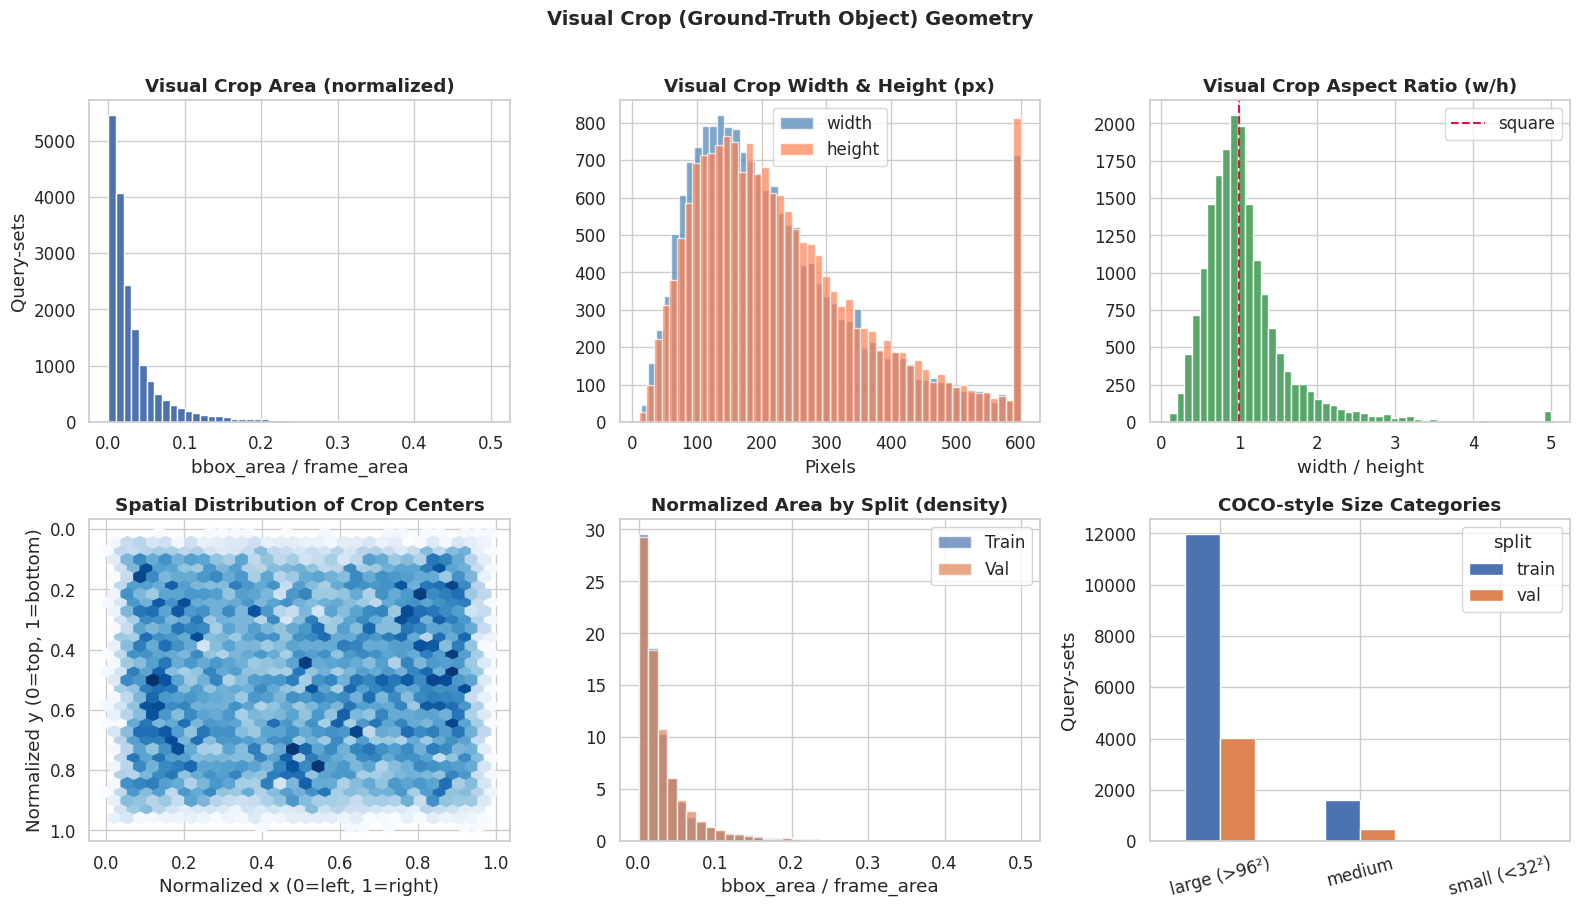


Size category distribution (% of valid query-sets):
size_cat
large (>96²)    88.2
medium          11.5
small (<32²)     0.3
Name: count, dtype: float64


In [24]:
# ── Visual crop size analysis ──────────────────────────────────────────────
valid = df[df.is_valid & df.vc_w.notna()].copy()

fig, axes = plt.subplots(2, 3, figsize=(16, 9))

# 1. Normalized area histogram
axes[0,0].hist(valid["vc_area_norm"].clip(upper=0.5), bins=50,
               color="#4C72B0", edgecolor="white")
axes[0,0].set_title("Visual Crop Area (normalized)", fontweight="bold")
axes[0,0].set_xlabel("bbox_area / frame_area")
axes[0,0].set_ylabel("Query-sets")

# 2. Width and height in pixels
axes[0,1].hist(valid["vc_w"].clip(upper=600), bins=50, alpha=0.7,
               color="steelblue", edgecolor="white", label="width")
axes[0,1].hist(valid["vc_h"].clip(upper=600), bins=50, alpha=0.7,
               color="coral", edgecolor="white", label="height")
axes[0,1].set_title("Visual Crop Width & Height (px)", fontweight="bold")
axes[0,1].set_xlabel("Pixels")
axes[0,1].legend()

# 3. Aspect ratio
axes[0,2].hist(valid["vc_aspect"].clip(0.1, 5), bins=50,
               color="#55A868", edgecolor="white")
axes[0,2].axvline(1.0, color="crimson", linestyle="--", linewidth=1.5, label="square")
axes[0,2].set_title("Visual Crop Aspect Ratio (w/h)", fontweight="bold")
axes[0,2].set_xlabel("width / height")
axes[0,2].legend()

# 4. Spatial heatmap of crop centers
axes[1,0].hexbin(valid["vc_cx_norm"], valid["vc_cy_norm"],
                 gridsize=30, cmap="Blues", mincnt=1)
axes[1,0].set_title("Spatial Distribution of Crop Centers", fontweight="bold")
axes[1,0].set_xlabel("Normalized x (0=left, 1=right)")
axes[1,0].set_ylabel("Normalized y (0=top, 1=bottom)")
axes[1,0].invert_yaxis()

# 5. Normalized area by split
for split, color in COLORS.items():
    subset = valid[valid.split == split]["vc_area_norm"].clip(upper=0.5)
    axes[1,1].hist(subset, bins=40, alpha=0.7, color=color,
                   label=split.title(), edgecolor="white", density=True)
axes[1,1].set_title("Normalized Area by Split (density)", fontweight="bold")
axes[1,1].set_xlabel("bbox_area / frame_area")
axes[1,1].legend()

# 6. Box size category breakdown
# Small (<32²), Medium (32²–96²), Large (>96²) — COCO convention scaled to 1440×1080
W, H = 1440, 1080
def size_cat(row):
    a = row["vc_w"] * row["vc_h"]
    if a < 32**2:   return "small (<32²)"
    if a < 96**2:   return "medium"
    return "large (>96²)"
valid["size_cat"] = valid.apply(size_cat, axis=1)
cat_counts = valid.groupby(["split", "size_cat"]).size().unstack(fill_value=0)
cat_counts.T.plot(kind="bar", ax=axes[1,2], color=[COLORS["train"], COLORS["val"]])
axes[1,2].set_title("COCO-style Size Categories", fontweight="bold")
axes[1,2].set_xlabel("")
axes[1,2].set_ylabel("Query-sets")
axes[1,2].tick_params(axis="x", rotation=15)

plt.suptitle("Visual Crop (Ground-Truth Object) Geometry", fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

print("\nSize category distribution (% of valid query-sets):")
print((100 * valid["size_cat"].value_counts() / len(valid)).round(1))

**Insights**

- The output above indicates that 88.2% of objects are large by COCO standards. Before drawing conclusions, it's worth interrogating whether the thresholds are meaningful here.

- The COCO thresholds were designed for a different context
COCO's small/medium/large cutoffs (32², 96², >96² pixels) were calibrated for a 640×480 dataset.

- Ego4D frames are 1440×1080 — roughly 5× more pixels. An object that would be "medium" in COCO resolution might be "large" here purely due to the higher resolution, not because the object is actually easy to detect.
A more meaningful comparison would be to normalize by frame area

In [25]:
print(df[df.is_valid]["vc_area_norm"].describe().round(4))
print(df[df.is_valid]["vc_area_norm"].quantile([0.1, 0.25, 0.5, 0.75, 0.9]).round(4))

count    18114.0000
mean         0.0357
std          0.0539
min          0.0001
25%          0.0083
50%          0.0186
75%          0.0400
max          0.9959
Name: vc_area_norm, dtype: float64
0.10    0.0040
0.25    0.0083
0.50    0.0186
0.75    0.0400
0.90    0.0828
Name: vc_area_norm, dtype: float64


What the normalized areas actually say

- 10th percentile : 0.004  →  0.4% of frame area
- 25th percentile : 0.008  →  0.8% of frame area
- 50th percentile : 0.019  →  1.9% of frame area
- 75th percentile : 0.040  →  4.0% of frame area
- 90th percentile : 0.083  →  8.3% of frame area

The median object occupies less than 2% of the frame. At 1440×1080, 2% of frame area is about 31,000 px², which corresponds to a square of roughly 176×176 pixels. That sounds reasonable for a cereal box or a mug seen from egocentric perspective — not tiny, but not large either.

The max of 0.9959 is almost certainly an outlier — an object filling essentially the entire frame, probably an annotation error or an extreme close-up.

**Revised take on the COCO classification**

The 88.2% "large" finding was purely a resolution artifact. When you look at normalized area, the distribution is actually quite small-biased — half the objects cover less than 2% of the frame. The COCO thresholds were just too coarse for a 1440×1080 dataset.

**Implication for YOLOv8 vs DETR**

This actually strengthens the case for YOLOv8 rather than weakening it.

- Small, egocentric objects with a median normalized area of 0.019 are exactly the regime where YOLOv8's anchor-free multi-scale detection tends to outperform DETR.

- DETR's global attention is powerful but its spatial resolution in the encoder is lower, which can hurt on small objects without additional tricks like deformable attention.

- This is a concrete, data-driven hypothesis we can state in your project writeup: **Given that 50% of objects occupy less than 2% of the frame, we hypothesize YOLOv8 will outperform vanilla DETR on this benchmark, and we test that hypothesis by...**

### Clip Metadata

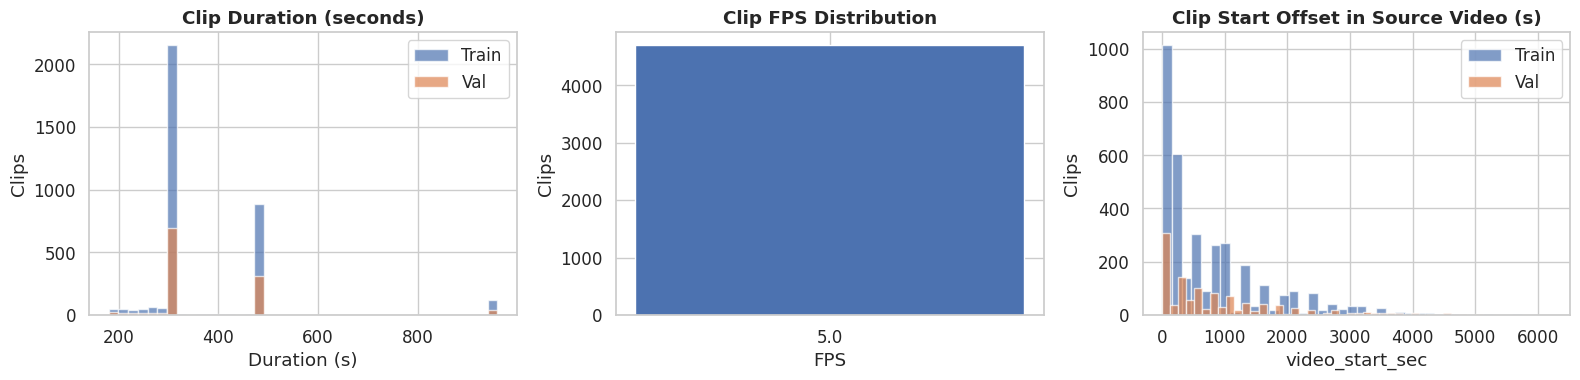

Unique FPS values: [np.float64(5.0)]

Clip duration stats (s):
count    4690.0
mean      367.2
std       143.5
min       179.9
25%       300.0
50%       300.0
75%       480.0
max       960.0
Name: clip_duration_sec, dtype: float64


In [26]:
# Clip-level view (one row per clip)
clip_df = df.drop_duplicates(subset="clip_uid").copy()

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# 1. Clip duration
for split, color in COLORS.items():
    subset = clip_df[clip_df.split == split]["clip_duration_sec"]
    axes[0].hist(subset, bins=40, alpha=0.7, color=color,
                 label=split.title(), edgecolor="white")
axes[0].set_title("Clip Duration (seconds)", fontweight="bold")
axes[0].set_xlabel("Duration (s)")
axes[0].set_ylabel("Clips")
axes[0].legend()

# 2. FPS distribution
fps_vals = clip_df["clip_fps"].value_counts().sort_index()
axes[1].bar(fps_vals.index.astype(str), fps_vals.values, color="#4C72B0")
axes[1].set_title("Clip FPS Distribution", fontweight="bold")
axes[1].set_xlabel("FPS")
axes[1].set_ylabel("Clips")

# 3. Video start offset (how deep into the source video each clip is)
for split, color in COLORS.items():
    subset = clip_df[clip_df.split == split]["video_start_sec"]
    axes[2].hist(subset, bins=40, alpha=0.7, color=color,
                 label=split.title(), edgecolor="white")
axes[2].set_title("Clip Start Offset in Source Video (s)", fontweight="bold")
axes[2].set_xlabel("video_start_sec")
axes[2].set_ylabel("Clips")
axes[2].legend()

plt.tight_layout()
plt.show()

print("Unique FPS values:", sorted(df["clip_fps"].unique()))
print("\nClip duration stats (s):")
print(clip_df["clip_duration_sec"].describe().round(1))

**Clip metadata**

All clips run at exactly 5 FPS — no variation to worry about, which simplifies frame extraction and FAISS indexing considerably.
The duration stats are interesting

- min :  180s  (3 min)
- 25% :  300s  (5 min)   ←┐
- 50% :  300s  (5 min)   ←┘ median = 25th percentile = same value
- 75% :  480s  (8 min)
- max :  960s  (16 min)

The median equaling the 25th percentile means a large mass of clips are pinned exactly at 300 seconds — these are likely standardized 5-minute clip segments from the Ego4D curation pipeline. The clips above 300s are probably longer activity recordings that weren't trimmed.

Implication for FAISS indexing: at 5 FPS, a 300-second clip = 1500 frames to embed and index per clip. At 960 seconds = 4800 frames. With 4690 clips total, the upper bound on total frames to embed is roughly 4690 × 1500 ≈ 7 million frames — that's the scale your CLIP/BLIP embedding step needs to handle. Worth factoring into our GCP compute planning before you hit notebook 04.


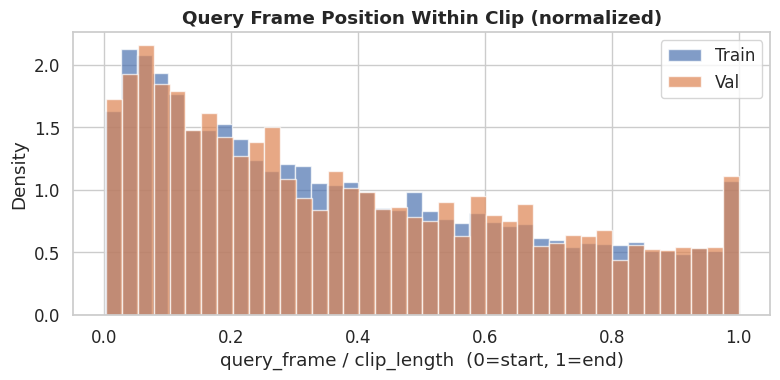

In [28]:
df["clip_total_frames"] = (df["clip_duration_sec"].fillna(0) * df["clip_fps"]).round().astype(int)
df["query_pos_norm"] = df["query_frame"] / df["clip_total_frames"].clip(lower=1)

fig, ax = plt.subplots(figsize=(8, 4))
for split, color in COLORS.items():
    subset = df[df.split == split]["query_pos_norm"].clip(0, 1)
    ax.hist(subset, bins=40, alpha=0.7, color=color,
            label=split.title(), edgecolor="white", density=True)
ax.set_title("Query Frame Position Within Clip (normalized)", fontweight="bold")
ax.set_xlabel("query_frame / clip_length  (0=start, 1=end)")
ax.set_ylabel("Density")
ax.legend()
plt.tight_layout()
plt.show()


- The plot — query frames cluster early in the clip
The distribution is right-skewed with peak density near 0.0–0.1, meaning most query frames fire in the first 10–20% of the clip. This makes intuitive sense for egocentric video — the camera wearer picks up or interacts with an object early in the recorded activity, sets it down, and the rest of the clip proceeds without it.

- The spike at exactly 1.0 is worth flagging — those are query frames at the very end of the clip, which may indicate annotation edge cases or clips where the object never reappeared after disappearing near the end. Worth filtering or examining separately if retrieval evaluation behaves oddly.

- Train and val track each other very closely throughout, which is a good sign — the splits are structurally consistent.

### Deeper Dive: Response Track Bounding Box Statistics

For **Problem 1 (object detection)**, training data = all bounding boxes in response tracks across all valid query-sets.

We may have to do a deeper dive in the future for the bounding box specifically The response track boxes capture the object in motion across multiple frames, whereas the visual crop is a static reference. Two things could differ:

- Size changes over time — an object being picked up moves toward the camera and grows. The visual crop might be systematically larger or smaller than the average response track box.

- Spatial distribution of where detection needs to fire — the heatmap of response track centers tells you where in the frame objects appear during tracking, which is more relevant to detection training than where the visual crop happens to be

### Finalized Summary

In [35]:
# ── Print a structured summary ─────────────────────────────────────────────
# Use the `valid` DataFrame that already has 'size_cat' computed
valid_all = valid
total_qs  = len(df) # `df` refers to `df_clean` which has all initially valid query-sets
valid_qs  = len(valid_all) # `valid_all` now refers to `valid`, which is also filtered and has `vc_w.notna()`

print("═" * 65)
print("  EgoRecall · EDA Summary")
print("═" * 65)

print("\n── Dataset Scale ───────────────────────────────────────────")
print(f"  Train videos        : {len(train_raw['videos']):,}")
print(f"  Val videos          : {len(val_raw['videos']):,}")
print(f"  Total query-sets    : {total_qs:,}")
print(f"  Valid query-sets    : {valid_qs:,}  ({100*valid_qs/total_qs:.1f}%)")
print(f"  Total RT boxes      : {len(rt_df):,}")

print("\n── Object Vocabulary ───────────────────────────────────────")
n_classes = len(title_counts)
top10_pct = 100 * sum(sorted(title_counts.values(), reverse=True)[:10]) / total_qs
print(f"  Unique object titles : {n_classes:,}")
print(f"  Top-10 classes cover : {top10_pct:.1f}% of queries")
print(f"  Singleton titles     : {len(singletons):,}")
print(f"  → Open-vocabulary retrieval (CLIP/BLIP) is essential")

print("\n── Detection (Problem 1) ───────────────────────────────────")
small_pct  = 100 * (valid_all["size_cat"] == "small (<32²)").sum() / valid_qs
large_pct  = 100 * (valid_all["size_cat"] == "large (>96²)").sum() / valid_qs
median_tl  = df[df.is_valid]["response_track_len"].median()
print(f"  Median track length  : {median_tl:.0f} frames")
print(f"  Small objects (<32²) : {small_pct:.1f}%")
print(f"  Large objects (>96²) : {large_pct:.1f}%")
print(f"  Resolution           : {int(valid_all.orig_w.mode()[0])}×{int(valid_all.orig_h.mode()[0])} px")

print("\n── Retrieval (Problem 2) ───────────────────────────────────")
fps_mode = clip_df["clip_fps"].mode()[0]
dur_med  = clip_df["clip_duration_sec"].median()
print(f"  Clip FPS (mode)      : {fps_mode}")
print(f"  Median clip length   : {dur_med:.0f}s  "
      f"(= {dur_med*fps_mode:.0f} frames to index)")
print(f"  → FAISS index per clip; visual_crop = query embedding")
print(f"  → CLIP text encoder can leverage object_title labels")
print(f"  → BLIP's image-text matching may handle ambiguous crops")
print("═" * 65)

═════════════════════════════════════════════════════════════════
  EgoRecall · EDA Summary
═════════════════════════════════════════════════════════════════

── Dataset Scale ───────────────────────────────────────────
  Train videos        : 1,321
  Val videos          : 422
  Total query-sets    : 18,114
  Valid query-sets    : 18,114  (100.0%)
  Total RT boxes      : 266,771

── Object Vocabulary ───────────────────────────────────────
  Unique object titles : 3,487
  Top-10 classes cover : 17.1% of queries
  Singleton titles     : 2,203
  → Open-vocabulary retrieval (CLIP/BLIP) is essential

── Detection (Problem 1) ───────────────────────────────────
  Median track length  : 10 frames
  Small objects (<32²) : 0.3%
  Large objects (>96²) : 88.2%
  Resolution           : 1920×1080 px

── Retrieval (Problem 2) ───────────────────────────────────
  Clip FPS (mode)      : 5.0
  Median clip length   : 300s  (= 1500 frames to index)
  → FAISS index per clip; visual_crop = query embeddin

In [34]:
print(df[["orig_w", "orig_h"]].value_counts().head(5))

orig_w  orig_h
1920.0  1080.0    6531
1440.0  1080.0    5706
1920.0  1440.0    4872
2560.0  1920.0     891
1280.0  720.0       63
Name: count, dtype: int64


**Notes on resolution**

- The vc_area_norm analysis we did earlier already normalizes by orig_w × orig_h, so those findings hold — the 1.9% median normalized area is resolution-agnostic.

- However the raw pixel thresholds we used for the COCO size categories (small <32², large >96²) are now even more clearly meaningless — a 32×32 pixel object means something very different in a 1280×720 frame versus a 2560×1920 frame.

- For detection training, both YOLOv8 and DETR expect a fixed input size. The standard approach is to resize everything to a common resolution during preprocessing.

- Given our resolutions, 1280×720 or 1920×1080 are natural choices — the first is more memory efficient, the latter preserves more detail for small objects which matters given our 1.9% median normalized area finding.

Total RT boxes: 266,771 — this is new and useful

- 266,771 labeled detection boxes across 18,114 query-sets averages to ~14.7 boxes per query-set, which matches the mean track length we saw earlier. This is your actual detection training set size — a solid number.

## Save Back Data to GCP

In [36]:
GCS_BUCKET = "gs://egorecall-data"

df.to_parquet("vq_query_sets.parquet", index=False)

!gsutil cp vq_query_sets.parquet {GCS_BUCKET}/processed/vq_query_sets.parquet

print("Saved to GCS:")
print(f"  {GCS_BUCKET}/processed/vq_query_sets.parquet")

Google recommends using Gcloud storage CLI (https://docs.cloud.google.com/storage/docs/discover-object-storage-gcloud) instead of gsutil. Please refer to migration guide (https://docs.cloud.google.com/storage/docs/gsutil-transition-to-gcloud) for assistance.
Copying file://vq_query_sets.parquet [Content-Type=application/octet-stream]...
/ [1 files][  2.1 MiB/  2.1 MiB]                                                
Operation completed over 1 objects/2.1 MiB.                                      
Saved to GCS:
  gs://egorecall-data/processed/vq_query_sets.parquet
